# Scenario I — Xception
## Notebook 2: Final Training & Results Visualisation
**Prerequisite:** Run NB1 (TPE) first to generate `tpe_xception.json`


## 0. Installation


In [1]:
# import subprocess, sys

# # Install PyTorch cu118 (compatible with compute capability 6.0 / P100)
# subprocess.check_call([
#     sys.executable, '-m', 'pip', 'install',
#     'torch==2.5.1+cu118',
#     'torchvision==0.20.1+cu118',
#     '--index-url', 'https://download.pytorch.org/whl/cu118',
#     '-q',
#     '--root-user-action=ignore',
#     '--disable-pip-version-check'
# ])

# print('Installation complete')
# print('IMPORTANT: restart the kernel before proceeding')

## 1. Imports, Seed & Device


In [2]:
import os, json, time, warnings, random, math
from pathlib import Path
from copy import deepcopy
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
import timm
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()

print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'USE_AMP : {USE_AMP}')


Device  : cuda
GPU     : Tesla P100-PCIE-16GB
VRAM    : 17.1 GB
USE_AMP : True


## 2. Configuration


In [3]:
# Paths
DS1_BASE  = Path('/kaggle/input/datasets/bhaveshmittal/melanoma-cancer-dataset')
DS1_TRAIN = DS1_BASE / 'train'
DS1_TEST  = DS1_BASE / 'test'
DS2_BASE  = Path('/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images')
DS2_TEST  = DS2_BASE / 'melanoma_cancer_dataset' / 'test'
OUTPUT_DIR = Path('/kaggle/working/full_pipeline_results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR   = OUTPUT_DIR / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

# Training config
NUM_CLASSES  = 2
NUM_WORKERS  = 4
GRAD_CLIP    = 1.0
TTA_STEPS    = 10

# ── Xception budget reduced to fit within the ~9-hour Kaggle limit ──────────
N_TRIALS        = 30
TPE_EPOCHS      = 12
TPE_ES_PAT      = 3
TPE_WARMUP_TR   = 10
FINAL_EPOCHS    = 35
VIT_FINAL_EP    = 30
ENS_TRIALS      = 100

# ── Improvement 2: Pretrained ViT via timm ──────────────────────────────────
VIT_MODEL_NAME  = 'vit_small_patch16_224'
VIT_IMG_SIZE    = 224

# ── Improvement 3: Accelerated unfreeze schedule ────────────────────────────
CNN_UNFREEZE = {
    1  : 'frozen',
    5  : 'last_block',
    10 : 'last_2_blocks',
    18 : 'full',
}

ARCH_CONFIGS = {
    'densenet121': {
        'label'            : 'DenseNet-121',
        'img_size'         : 224,
        'unfreeze_schedule': CNN_UNFREEZE,
    },
    'inception_v3': {
        'label'            : 'InceptionV3',
        'img_size'         : 299,
        'unfreeze_schedule': CNN_UNFREEZE,
    },
    'xception': {
        'label'            : 'Xception',
        'img_size'         : 299,
        'unfreeze_schedule': CNN_UNFREEZE,
    },
}

MODEL_LABELS = {
    'densenet121'  : 'DenseNet-121',
    'inception_v3' : 'InceptionV3',
    'xception'     : 'Xception',
    'vit_scratch'  : 'ViT-Pretrained',
}

PAPER_REF = {
    'DenseNet-121'    : {'accuracy':0.9450, 'precision':0.9390,
                          'recall':0.9504,   'f1':0.9447},
    'InceptionV3'     : {'accuracy':0.9120, 'precision':0.9320,
                          'recall':0.8962,   'f1':0.9137},
    'Xception'        : {'accuracy':0.9380, 'precision':0.9300,
                          'recall':0.9451,   'f1':0.9375},
    'ViT-Pretrained'  : {'accuracy':0.8825, 'precision':0.9050,
                          'recall':0.8660,   'f1':0.8850},
    'Ensemble'        : {'accuracy':0.9525, 'precision':0.9420,
                          'recall':0.9622,   'f1':0.9520},
}

print('Configuration loaded successfully')
print(f'  N_TRIALS     = {N_TRIALS}  (was 15)')
print(f'  TPE_EPOCHS   = {TPE_EPOCHS}  (was 8)')
print(f'  TPE_ES_PAT   = {TPE_ES_PAT}  (was 2)')
print(f'  FINAL_EPOCHS = {FINAL_EPOCHS}  (was 30)')
print(f'  VIT_FINAL_EP = {VIT_FINAL_EP}  (was 40)')
print(f'  ENS_TRIALS   = {ENS_TRIALS}  (was 30)')
print(f'  ViT model    = {VIT_MODEL_NAME}  (was ViT-B/16 from scratch)')
print(f'  Unfreeze full at epoch {max(CNN_UNFREEZE.keys())} of {FINAL_EPOCHS}'
      f'  → {FINAL_EPOCHS - max(CNN_UNFREEZE.keys())} epoch full fine-tuning  (was 8)')
print()
print('Baseline Paper Reference:')
print(f'{"Model":<18} {"Accuracy":>10} {"Recall":>8} {"F1":>8}')
print('-' * 46)
for model, vals in PAPER_REF.items():
    print(f'{model:<18} {vals["accuracy"]:>10.2%} '
          f'{vals["recall"]:>8.2%} {vals["f1"]:>8.2%}')


Configuration loaded successfully
  N_TRIALS     = 30  (was 15)
  TPE_EPOCHS   = 12  (was 8)
  TPE_ES_PAT   = 3  (was 2)
  FINAL_EPOCHS = 35  (was 30)
  VIT_FINAL_EP = 30  (was 40)
  ENS_TRIALS   = 100  (was 30)
  ViT model    = vit_small_patch16_224  (was ViT-B/16 from scratch)
  Unfreeze full at epoch 18 of 35  → 17 epoch full fine-tuning  (was 8)

Baseline Paper Reference:
Model                Accuracy   Recall       F1
----------------------------------------------
DenseNet-121           94.50%   95.04%   94.47%
InceptionV3            91.20%   89.62%   91.37%
Xception               93.80%   94.51%   93.75%
ViT-Pretrained         88.25%   86.60%   88.50%
Ensemble               95.25%   96.22%   95.20%


## 3. Data Pipeline


In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_transforms(split, img_size):
    if split == 'train':
        return transforms.Compose([
            transforms.Resize((img_size + 24, img_size + 24)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(25),
            transforms.ColorJitter(0.15, 0.15, 0.15, 0.08),
            transforms.RandomAffine(
                0, translate=(0.1, 0.1),
                scale=(0.85, 1.15), shear=5),
            transforms.RandomGrayscale(p=0.05),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            transforms.RandomErasing(p=0.15, scale=(0.02, 0.1)),
        ])
    elif split == 'tta':
        return transforms.Compose([
            transforms.Resize((img_size + 16, img_size + 16)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])


def build_dataloaders(batch_size, img_size, val_split=0.15):
    full_ds = ImageFolder(
        DS1_TRAIN, transform=get_transforms('train', img_size))
    targets = [s[1] for s in full_ds.samples]
    cc      = [targets.count(i) for i in range(NUM_CLASSES)]

    tr_idx, vl_idx = train_test_split(
        range(len(full_ds)), test_size=val_split,
        stratify=targets, random_state=SEED)

    tr_ds   = Subset(full_ds, tr_idx)
    vl_base = ImageFolder(
        DS1_TRAIN, transform=get_transforms('val', img_size))
    vl_ds   = Subset(vl_base, vl_idx)

    tr_tgt   = np.array(targets)[tr_idx]
    class_cnt = np.bincount(tr_tgt)
    # Use sqrt inverse frequency (softer than pure inverse)
    # Pure inverse tends to over-correct; sqrt is a well-balanced compromise
    class_w  = 1.0 / np.sqrt(class_cnt.astype(float))
    class_w  = class_w / class_w.sum() * len(class_cnt)  # normalise
    sw       = class_w[tr_tgt]
    smp      = WeightedRandomSampler(
        torch.DoubleTensor(sw), len(sw) * 2, replacement=True)
    # × 2 ensures the minority class is sufficiently represented each epoch

    tr_ld = DataLoader(
        tr_ds, batch_size, sampler=smp,
        num_workers=NUM_WORKERS, pin_memory=True)
    vl_ld = DataLoader(
        vl_ds, batch_size, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True)
    te_ds = ImageFolder(
        DS1_TEST, transform=get_transforms('test', img_size))
    te_ld = DataLoader(
        te_ds, 32, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True)

    return tr_ld, vl_ld, te_ld, full_ds.classes, cc


_, _, _, CLASS_NAMES, _ = build_dataloaders(32, 224)
print(f'Class names : {CLASS_NAMES}')


Class names : ['Benign', 'Malignant']


## 4. Model Factory


In [5]:
# ── Improvement 4: CNN with a richer custom classification head ─────────────

class CNNWithHead(nn.Module):
    """CNN wrapper with custom head: GAP → BN → GELU → Dropout → Linear.
    Provides greater adaptation capacity than the default timm head.
    """
    def __init__(self, backbone, n_features, dropout, num_classes):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Linear(n_features, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )
        self._init_head()

    def _init_head(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.head(self.backbone(x))


def build_cnn(arch_name, dropout):
    """Build a pretrained CNN with a 512-dim custom classification head."""
    # num_classes=0 → timm returns features without classification head
    backbone   = timm.create_model(
        arch_name, pretrained=True,
        drop_rate=dropout, num_classes=0)
    n_features = backbone.num_features
    return CNNWithHead(backbone, n_features, dropout, NUM_CLASSES)


def apply_freeze(model, strategy):
    # Handle both CNNWithHead and plain model types
    if isinstance(model, CNNWithHead):
        params = list(model.backbone.named_parameters())
        # Classification head is always kept trainable
        for p in model.head.parameters():
            p.requires_grad_(True)
    else:
        params = list(model.named_parameters())

    total = len(params)
    for _, p in params:
        p.requires_grad_(False)

    # Always keep backbone classification layers trainable
    for name, p in params:
        if any(k in name for k in ('head', 'classifier', 'fc', 'last_linear', 'norm')):
            p.requires_grad_(True)

    if strategy == 'last_block':
        for i, (_, p) in enumerate(params):
            if i >= int(total * 0.85):
                p.requires_grad_(True)
    elif strategy == 'last_2_blocks':
        for i, (_, p) in enumerate(params):
            if i >= int(total * 0.70):
                p.requires_grad_(True)
    elif strategy == 'full':
        for _, p in params:
            p.requires_grad_(True)
        if isinstance(model, CNNWithHead):
            for p in model.head.parameters():
                p.requires_grad_(True)

    tr  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    tot = sum(p.numel() for p in model.parameters())
    return model, tr, tot


def progressive_unfreeze(model, epoch, schedule):
    strategy = 'frozen'
    for ep, strat in sorted(schedule.items()):
        if epoch >= ep:
            strategy = strat
    model, tr, _ = apply_freeze(model, strategy)
    return model, strategy, tr


# ── Improvement 5: Extended optimizer support including Adamax ───────────────

def build_optimizer(model, opt_name, lr, wd, layer_decay=None):
    """Build optimizer. If layer_decay is provided, applies LLRD for ViT."""
    if layer_decay is not None and hasattr(model, 'blocks'):
        # Layer-wise LR Decay (LLRD) for pretrained ViT
        depth  = len(model.blocks)
        groups = []
        # Classification head receives the full learning rate
        groups.append({'params': list(model.head.parameters()), 'lr': lr})
        groups.append({'params': list(model.norm.parameters()),  'lr': lr})
        # Each block receives progressively smaller LR towards the input
        for i, block in enumerate(reversed(model.blocks)):
            decay_factor = layer_decay ** (i + 1)
            groups.append({'params': list(block.parameters()), 'lr': lr * decay_factor})
        # Patch embedding and positional embedding
        groups.append({'params': [model.patch_embed.proj.weight,
                                   model.patch_embed.proj.bias,
                                   model.cls_token, model.pos_embed],
                       'lr': lr * (layer_decay ** (depth + 1))})
        return optim.AdamW(groups, weight_decay=wd)

    params = [p for p in model.parameters() if p.requires_grad]
    if opt_name == 'adam':
        return optim.Adam(params, lr=lr, weight_decay=wd)
    elif opt_name == 'adamax':
        return optim.Adamax(params, lr=lr, weight_decay=wd)
    return optim.AdamW(params, lr=lr, weight_decay=wd)


# ── Improvement 6: Loss function — Focal vs CE+LabelSmoothing selection ────────

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = (torch.tensor(alpha, dtype=torch.float32).to(DEVICE)
                      if alpha is not None else None)

    def forward(self, logits, targets):
        log_p  = F.log_softmax(logits, dim=1)
        ce     = F.nll_loss(log_p, targets, reduction='none')
        focal  = (1 - torch.exp(-ce)) ** self.gamma * ce
        if self.alpha is not None:
            focal = self.alpha[targets] * focal
        return focal.mean()


def build_criterion(use_focal, focal_gamma, label_smoothing, class_counts=None):
    """Select one: Focal Loss OR CrossEntropy+LabelSmoothing.
    Class weighting uses Effective Number of Samples.
    Superior to inverse-frequency weighting for moderate class imbalance.
    """
    alpha = None
    if class_counts:
        # Effective Number of Samples: (1 - beta^n) / (1 - beta)
        beta  = 0.9999
        eff   = [(1.0 - beta ** c) / (1.0 - beta) for c in class_counts]
        raw_a = [1.0 / e for e in eff]
        s     = sum(raw_a)
        # Normalise so mean weight ≈ 1.0 (improves training stability)
        alpha = [v / s * len(class_counts) for v in raw_a]

    if use_focal:
        return FocalLoss(gamma=focal_gamma, alpha=alpha)
    else:
        return nn.CrossEntropyLoss(
            label_smoothing=label_smoothing,
            weight=torch.tensor(alpha, dtype=torch.float32).to(DEVICE)
                  if alpha else None)


# ── Improvement 7: Pretrained ViT loaded from timm ──────────────────────────

def build_vit_pretrained(dropout):
    """ViT-Small/16 pretrained on ImageNet — substantially better than training from scratch."""
    model = timm.create_model(
        VIT_MODEL_NAME,
        pretrained=True,
        drop_rate=dropout,
        attn_drop_rate=dropout * 0.5,
        drop_path_rate=0.1,
        num_classes=NUM_CLASSES,
    )
    # Replace the default head with a richer two-layer variant
    in_features  = model.head.in_features
    model.head   = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(256, NUM_CLASSES),
    )
    return model


# Sanity check
_cnn = build_cnn('densenet121', 0.3).to(DEVICE)
_x   = torch.randn(2, 3, 224, 224).to(DEVICE)
_o   = _cnn(_x)
print(f'CNN output shape     : {tuple(_o.shape)}')
print(f'CNN total params     : {sum(p.numel() for p in _cnn.parameters())/1e6:.1f}M')

_vit = build_vit_pretrained(0.1).to(DEVICE)
_x2  = torch.randn(2, 3, 224, 224).to(DEVICE)
_o2  = _vit(_x2)
print(f'ViT output shape     : {tuple(_o2.shape)}')
print(f'ViT total params     : {sum(p.numel() for p in _vit.parameters())/1e6:.1f}M')
print(f'ViT model name       : {VIT_MODEL_NAME}  (pretrained=True)')

del _cnn, _vit, _x, _x2, _o, _o2
torch.cuda.empty_cache()
print('\nModel factory v2 ready')


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

CNN output shape     : (2, 2)
CNN total params     : 7.5M


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

ViT output shape     : (2, 2)
ViT total params     : 21.8M
ViT model name       : vit_small_patch16_224  (pretrained=True)

Model factory v2 ready


## 5. Training & Evaluation Utilities


In [6]:
def train_one_epoch(model, loader, optimizer, criterion,
                    scaler, clip=None):
    model.train()
    loss_sum = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=USE_AMP):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        if clip:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), clip)
        scaler.step(optimizer)
        scaler.update()
        loss_sum += loss.item() * imgs.size(0)
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    loss_sum = correct = total = 0
    all_p, all_l = [], []
    crit = criterion or nn.CrossEntropyLoss()
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with autocast(enabled=USE_AMP):
            logits = model(imgs)
            loss   = crit(logits, labels)
        probs = torch.softmax(logits, 1)[:, 1]
        loss_sum += loss.item() * imgs.size(0)
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += imgs.size(0)
        all_p.extend(probs.cpu().numpy())
        all_l.extend(labels.cpu().numpy())
    acc = correct / total
    try:
        auc = roc_auc_score(all_l, all_p)
    except Exception:
        auc = 0.0
    return (loss_sum / total, acc, auc,
            np.array(all_l), np.array(all_p))


@torch.no_grad()
def get_probs(model, ds_root, img_size, n_tta=1):
    model.eval()
    base_ds = ImageFolder(
        ds_root, transform=get_transforms('test', img_size))
    base_ld = DataLoader(
        base_ds, 32, shuffle=False, num_workers=NUM_WORKERS)
    labels_all = []
    probs_all  = np.zeros(len(base_ds), dtype=np.float32)
    idx = 0
    for imgs, labs in base_ld:
        with autocast(enabled=USE_AMP):
            p = torch.softmax(
                model(imgs.to(DEVICE)), 1)[:, 1].cpu().numpy()
        probs_all[idx:idx + len(p)] += p
        labels_all.extend(labs.numpy())
        idx += len(p)
    for _ in range(n_tta - 1):
        ds = ImageFolder(
            ds_root, transform=get_transforms('tta', img_size))
        ld = DataLoader(
            ds, 32, shuffle=False, num_workers=NUM_WORKERS)
        idx = 0
        for imgs, _ in ld:
            with autocast(enabled=USE_AMP):
                p = torch.softmax(
                    model(imgs.to(DEVICE)), 1)[:, 1].cpu().numpy()
            probs_all[idx:idx + len(p)] += p
            idx += len(p)
    return np.array(labels_all), probs_all / n_tta


def compute_metrics(labels, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    return {
        'accuracy'  : accuracy_score(labels, preds),
        'precision' : precision_score(labels, preds, zero_division=0),
        'recall'    : recall_score(labels, preds, zero_division=0),
        'f1'        : f1_score(labels, preds, zero_division=0),
        'auc'       : roc_auc_score(labels, probs),
        'conf_mat'  : confusion_matrix(labels, preds).tolist(),
        'threshold' : float(threshold),
    }


print('Utilities ready')
print(f'  USE_AMP = {USE_AMP}')


Utilities ready
  USE_AMP = True


## 6. TPE Search + Final Training


In [7]:
def make_cnn_objective(arch_name):
    img_size = ARCH_CONFIGS[arch_name]['img_size']
    n = {'i': 0}

    def objective(trial):
        n['i'] += 1

        # ── Architecture-specific hyperparameter search space ──────────
        if arch_name == 'densenet121':
            lr  = trial.suggest_float('lr',  3e-4, 1.5e-2, log=True)
            bs  = trial.suggest_categorical('batch_size', [32, 64])
            do  = trial.suggest_float('dropout', 0.15, 0.45)
            wd  = trial.suggest_float('weight_decay', 1e-6, 5e-4, log=True)
            ui  = trial.suggest_categorical('unfreeze_init',
                      ['last_block', 'last_2_blocks'])
            opt = trial.suggest_categorical('optimizer_name',
                      ['adam', 'adamw', 'adamax'])
            uf  = trial.suggest_categorical('use_focal', [True, False])
            fg  = trial.suggest_float('focal_gamma', 0.5, 2.5)
            ls  = trial.suggest_float('label_smoothing', 0.00, 0.12)
            sc  = trial.suggest_categorical('scheduler_type', ['cosine', 'onecycle'])

        elif arch_name == 'inception_v3':
            lr  = trial.suggest_float('lr',  2e-4, 8e-3, log=True)
            bs  = trial.suggest_categorical('batch_size', [32, 64])
            do  = trial.suggest_float('dropout', 0.20, 0.55)
            wd  = trial.suggest_float('weight_decay', 1e-6, 5e-4, log=True)
            ui  = trial.suggest_categorical('unfreeze_init',
                      ['last_block', 'last_2_blocks'])
            opt = trial.suggest_categorical('optimizer_name',
                      ['adam', 'adamw', 'adamax'])
            uf  = trial.suggest_categorical('use_focal', [True, False])
            fg  = trial.suggest_float('focal_gamma', 0.5, 2.5)
            ls  = trial.suggest_float('label_smoothing', 0.02, 0.15)
            sc  = trial.suggest_categorical('scheduler_type', ['cosine', 'onecycle'])

        else:  # xception
            lr  = trial.suggest_float('lr',  1e-4, 5e-3, log=True)
            bs  = trial.suggest_categorical('batch_size', [32, 64])
            do  = trial.suggest_float('dropout', 0.25, 0.55)
            wd  = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
            ui  = trial.suggest_categorical('unfreeze_init',
                      ['last_block', 'last_2_blocks'])
            opt = trial.suggest_categorical('optimizer_name',
                      ['adam', 'adamw', 'adamax'])
            uf  = trial.suggest_categorical('use_focal', [True, False])
            fg  = trial.suggest_float('focal_gamma', 0.5, 2.5)
            ls  = trial.suggest_float('label_smoothing', 0.03, 0.15)
            sc  = trial.suggest_categorical('scheduler_type', ['cosine', 'onecycle'])

        print(f'  Trial {n["i"]:>2}/{N_TRIALS} '
              f'lr={lr:.2e} bs={bs} do={do:.2f} '
              f'opt={opt} frz={ui} '
              f'focal={uf} sc={sc}',
              end=' -> ')
        try:
            model = build_cnn(arch_name, do).to(DEVICE)
            model, _, _ = apply_freeze(model, ui)
            tr_ld, vl_ld, _, _, cc = build_dataloaders(bs, img_size)
            optimizer = build_optimizer(model, opt, lr, wd)
            criterion = build_criterion(uf, fg, ls, cc)

            if sc == 'onecycle':
                scheduler = optim.lr_scheduler.OneCycleLR(
                    optimizer, max_lr=lr,
                    steps_per_epoch=len(tr_ld),
                    epochs=TPE_EPOCHS,
                    pct_start=0.3, div_factor=10.0,
                    final_div_factor=100.0)
                step_per_batch = True
            else:
                scheduler = optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=TPE_EPOCHS, eta_min=lr * 0.01)
                step_per_batch = False

            scaler   = GradScaler(enabled=USE_AMP)
            best_acc = 0.0
            no_impr  = 0

            for ep in range(TPE_EPOCHS):
                if step_per_batch:
                    # OneCycleLR requires scheduler.step() after every batch
                    model.train()
                    for xb, yb in tr_ld:
                        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                        optimizer.zero_grad()
                        with autocast(enabled=USE_AMP):
                            loss = criterion(model(xb), yb)
                        scaler.scale(loss).backward()
                        scaler.unscale_(optimizer)
                        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                        scaler.step(optimizer)
                        scaler.update()
                        scheduler.step()
                else:
                    train_one_epoch(model, tr_ld, optimizer, criterion,
                                    scaler, GRAD_CLIP)

                _, val_acc, _, _, _ = evaluate(model, vl_ld, criterion)
                if not step_per_batch:
                    scheduler.step()

                if val_acc > best_acc:
                    best_acc = val_acc
                    no_impr  = 0
                else:
                    no_impr += 1
                if no_impr >= TPE_ES_PAT:
                    break

            print(f'acc={best_acc:.4f}')
            del model, optimizer, scheduler, scaler, tr_ld, vl_ld
            torch.cuda.empty_cache()
            return best_acc
        except Exception as e:
            print(f'ERROR: {e}')
            torch.cuda.empty_cache()
            return 0.0
    return objective


# ── FIX #1: Helper scheduler baru yang menghormati scheduler_type dari TPE ──
def _build_phase_scheduler(optimizer, sc_type, lr, n_epochs, tr_ld):
    """Buat scheduler per unfreeze phase sesuai sc_type hasil TPE.

    OneCycleLR TIDAK kompatibel dengan progressive unfreeze karena scheduler
    di-reset di setiap phase, sedangkan OneCycleLR mengharapkan total_steps
    yang tetap sejak awal. Sebagai gantinya, jika TPE memilih 'onecycle',
    digunakan CosineAnnealingWarmRestarts yang memberikan perilaku serupa
    (warm restart, penurunan LR tajam) namun kompatibel dengan reset.
    """
    if sc_type == 'onecycle':
        # Pengganti OneCycle yang kompatibel dengan unfreeze reset.
        # T_0=4 memberikan satu warm restart per ~4 epoch (mirip pct_start OneCycle).
        return optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=max(4, n_epochs // 4), T_mult=1,
            eta_min=lr * 1e-2)
    else:
        return optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=n_epochs, eta_min=lr * 5e-3)


def run_final_cnn(arch_name, bp):
    img_size  = ARCH_CONFIGS[arch_name]['img_size']
    schedule  = ARCH_CONFIGS[arch_name]['unfreeze_schedule']
    # FIX #1: baca scheduler_type dari hasil TPE (default 'cosine' jika tidak ada)
    sc_type   = bp.get('scheduler_type', 'cosine')

    model = build_cnn(arch_name, bp['dropout'])
    model, _, _ = apply_freeze(model, 'frozen')
    model = model.to(DEVICE)

    tr_ld, vl_ld, _, _, cc = build_dataloaders(bp['batch_size'], img_size)
    optimizer = build_optimizer(model, bp['optimizer_name'],
                                bp['lr'], bp['weight_decay'])
    criterion = build_criterion(bp['use_focal'], bp['focal_gamma'],
                                bp['label_smoothing'], cc)
    scaler = GradScaler(enabled=USE_AMP)

    # FIX #1: gunakan _build_phase_scheduler agar menghormati sc_type dari TPE
    # T_max=4: covers frozen phase (epochs 1-4) sebelum first unfreeze
    scheduler = _build_phase_scheduler(optimizer, sc_type, bp['lr'], 4, tr_ld)
    print(f'  [FIX] scheduler_type dari TPE: {sc_type} '
          f'-> menggunakan {type(scheduler).__name__}')

    best_val_acc = 0.0
    best_state   = None
    best_epoch   = 0
    prev_strat   = None
    vl_labels_best = None
    vl_probs_best  = None
    history = {'train_loss':[], 'val_loss':[],
               'train_acc':[], 'val_acc':[],
               'val_auc':[], 'freeze_strategy':[]}

    for epoch in range(1, FINAL_EPOCHS + 1):
        t_ep = time.time()
        model, cur_strat, n_tr = progressive_unfreeze(model, epoch, schedule)

        if cur_strat != prev_strat:
            # LR scale per strategy — prevents catastrophic forgetting during full unfreeze
            LR_SCALE = {
                'frozen'       : 1.00,
                'last_block'   : 0.20,
                'last_2_blocks': 0.08,
                'full'         : 0.02,
            }
            cur_lr = bp['lr'] * LR_SCALE.get(cur_strat, 0.02)
            print(f'  Epoch {epoch}: strategy -> {cur_strat} '
                  f'({n_tr:,} params trainable), '
                  f'lr={cur_lr:.2e}  (scale={LR_SCALE[cur_strat]:.2f})')

            if cur_strat == 'full' and isinstance(model, CNNWithHead):
                # Differential LR: head receives 5x higher LR than backbone
                param_groups = [
                    {'params': list(model.head.parameters()),
                     'lr': cur_lr * 5.0},
                    {'params': list(model.backbone.parameters()),
                     'lr': cur_lr},
                ]
                opt_name = bp['optimizer_name']
                wd       = bp['weight_decay']
                if opt_name == 'adam':
                    optimizer = optim.Adam(param_groups,  weight_decay=wd)
                elif opt_name == 'adamax':
                    optimizer = optim.Adamax(param_groups, weight_decay=wd)
                else:
                    optimizer = optim.AdamW(param_groups,  weight_decay=wd)
            else:
                optimizer = build_optimizer(model, bp['optimizer_name'],
                                            cur_lr, bp['weight_decay'])

            # FIX #1: reset scheduler per phase menggunakan helper yang menghormati sc_type
            remaining = FINAL_EPOCHS - epoch + 1
            scheduler = _build_phase_scheduler(
                optimizer, sc_type, cur_lr, remaining, tr_ld)
            prev_strat = cur_strat

        tr_loss, tr_acc = train_one_epoch(
            model, tr_ld, optimizer, criterion, scaler, GRAD_CLIP)
        vl_loss, vl_acc, vl_auc, vl_labels, vl_probs = evaluate(
            model, vl_ld, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        history['val_auc'].append(vl_auc)
        history['freeze_strategy'].append(cur_strat)

        if vl_acc > best_val_acc:
            best_val_acc   = vl_acc
            best_state     = deepcopy(model.state_dict())
            best_epoch     = epoch
            vl_labels_best = vl_labels
            vl_probs_best  = vl_probs
            torch.save({
                'arch'        : arch_name,
                'state_dict'  : best_state,
                'best_params' : bp,
                'best_epoch'  : best_epoch,
                'best_val_acc': best_val_acc,
                'img_size'    : img_size,
            }, OUTPUT_DIR / f'{arch_name}_best.pth')
            mark = ' <- best'
        else:
            mark = ''

        cur_lr = optimizer.param_groups[0]['lr']
        print(f'  Ep {epoch:>2}/{FINAL_EPOCHS} '
              f'loss {tr_loss:.4f}/{vl_loss:.4f} '
              f'acc {tr_acc:.4f}/{vl_acc:.4f} '
              f'auc {vl_auc:.4f} '
              f'lr={cur_lr:.2e} '
              f'{time.time()-t_ep:.0f}s{mark}')

    model.load_state_dict(best_state)
    print(f'  Best weights from epoch {best_epoch} '
          f'(val acc={best_val_acc:.4f})')
    return model, vl_labels_best, vl_probs_best, history, best_epoch


## 7. Load Best Params from NB1 (TPE)


In [8]:
# ── Load best hyperparameters from NB1 TPE results ──────────────────────────
OUTPUT_DIR = Path('/kaggle/working/full_pipeline_results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR   = OUTPUT_DIR / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

arch_name = 'xception'

tpe_json_path = Path('/kaggle/input/models/rofiq20/xception-model-check-point/pytorch/default/1') / f'tpe_{arch_name}.json'
with open(tpe_json_path) as f:
    tpe_best_params_loaded = json.load(f)

bp = {k: v for k, v in tpe_best_params_loaded.items() if k != 'best_val_acc'}
print(f'Loaded best params from: {tpe_json_path}')
print(f'Best val acc (TPE)  : {tpe_best_params_loaded["best_val_acc"]:.4f}')
print(f'Best params: {bp}')


Loaded best params from: /kaggle/input/models/rofiq20/xception-model-check-point/pytorch/default/1/tpe_xception.json
Best val acc (TPE)  : 0.9091
Best params: {'lr': 0.00043284502212938834, 'batch_size': 32, 'dropout': 0.429597545259111, 'weight_decay': 2.9380279387035354e-06, 'unfreeze_init': 'last_block', 'optimizer_name': 'adam', 'use_focal': False, 'focal_gamma': 2.1648852816008435, 'label_smoothing': 0.055480693281393136, 'scheduler_type': 'onecycle'}


## 8. Final Training & Evaluasi


In [9]:
# ── Final Training ────────────────────────────────────────────────────────────
all_models      = {}
all_probs_ds1   = {}
all_val_probs   = {}
all_metrics_ds1 = {}
all_val_labels  = None
ds1_labels      = None
tpe_best_params = {arch_name: {**bp, 'best_val_acc': tpe_best_params_loaded['best_val_acc']}}

arch_cfg  = ARCH_CONFIGS[arch_name]
label     = arch_cfg['label']
img_size  = arch_cfg['img_size']

print(f'\n  Final Training — {FINAL_EPOCHS} epochs')
model, vl_labels, vl_probs, history, best_ep = run_final_cnn(arch_name, bp)

all_val_probs[arch_name] = vl_probs
all_val_labels = vl_labels

torch.save({
    'arch'       : arch_name,
    'state_dict' : model.state_dict(),
    'best_params': bp,
    'best_epoch' : best_ep,
    'history'    : history,
    'img_size'   : img_size,
}, CKPT_DIR / f'{arch_name}_best.pth')

labels, probs = get_probs(model, DS1_TEST, img_size, TTA_STEPS)
m = compute_metrics(labels, probs)

all_models[arch_name]      = model
all_probs_ds1[arch_name]   = probs
all_metrics_ds1[arch_name] = m
ds1_labels = labels

paper = PAPER_REF[label]
print(f'\n  {label} Results (TTA ×{TTA_STEPS}) vs. Baseline Paper:')
print(f'  {"Metric":<12} {"Ours":>8} {"Paper":>8} {"Delta":>9}')
print('  ' + '-' * 40)
for k in ['accuracy', 'precision', 'recall', 'f1']:
    d = m[k] - paper[k]
    sign = 'OK' if d >= 0 else 'BELOW'
    print(f'  {k:<12} {m[k]:>8.4f} '
          f'{paper[k]:>8.4f} {d:>+9.4f}  {sign}')

torch.cuda.empty_cache()

# Save probabilities and labels
np.save(OUTPUT_DIR / f'probs_ds1_{arch_name}.npy', probs)
np.save(OUTPUT_DIR / f'val_probs_{arch_name}.npy', vl_probs)
np.save(OUTPUT_DIR / f'val_labels.npy', vl_labels)
np.save(OUTPUT_DIR / f'ds1_labels.npy', labels)
print(f'\nProbabilities saved to {OUTPUT_DIR}')



  Final Training — 35 epochs


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth


  [FIX] scheduler_type dari TPE: onecycle -> menggunakan CosineAnnealingWarmRestarts
  Epoch 1: strategy -> frozen (1,051,138 params trainable), lr=4.33e-04  (scale=1.00)
  Ep  1/35 loss 0.4252/0.3910 acc 0.8334/0.8558 auc 0.9290 lr=4.17e-04 146s <- best
  Ep  2/35 loss 0.3992/0.3870 acc 0.8479/0.8625 auc 0.9319 lr=3.70e-04 140s <- best
  Ep  3/35 loss 0.3949/0.3989 acc 0.8504/0.8547 auc 0.9283 lr=3.01e-04 140s
  Ep  4/35 loss 0.3872/0.4037 acc 0.8565/0.8541 auc 0.9280 lr=2.19e-04 140s
  Epoch 5: strategy -> last_block (8,378,242 params trainable), lr=8.66e-05  (scale=0.20)
  Ep  5/35 loss 0.3690/0.3849 acc 0.8691/0.8569 auc 0.9399 lr=8.23e-05 145s
  Ep  6/35 loss 0.3378/0.3487 acc 0.8891/0.8878 auc 0.9510 lr=7.04e-05 145s <- best
  Ep  7/35 loss 0.3188/0.3446 acc 0.8973/0.8923 auc 0.9514 lr=5.33e-05 146s <- best
  Ep  8/35 loss 0.3063/0.3618 acc 0.9041/0.8799 auc 0.9492 lr=3.42e-05 146s
  Ep  9/35 loss 0.2953/0.3446 acc 0.9114/0.8911 auc 0.9545 lr=1.70e-05 146s
  Epoch 10: strategy ->

## 9. DS2 Generalization


In [10]:
import numpy as np

ds2_labels, ds2_probs = get_probs(model, DS2_TEST, 299, TTA_STEPS)
np.save(OUTPUT_DIR / 'probs_ds2_xception.npy', ds2_probs)
np.save(OUTPUT_DIR / 'ds2_labels.npy',         ds2_labels)

m  = compute_metrics(ds2_labels, ds2_probs)
d1 = all_metrics_ds1['xception']

print(f"\nXception — DS1 vs DS2 Generalization:")
print(f"  {'Metric':<12} {'DS1':>8} {'DS2':>8} {'Delta':>10}")
print("  " + "-" * 42)
for k in ['accuracy', 'precision', 'recall', 'f1']:
    diff = m[k] - d1[k]
    print(f"  {k:<12} {d1[k]:>8.4f} {m[k]:>8.4f} {diff:>+10.4f}  {'▼' if diff<0 else '▲'}")

print(f"\nSaved: probs_ds2_xception.npy")
print(f"Saved: ds2_labels.npy")



Xception — DS1 vs DS2 Generalization:
  Metric            DS1      DS2      Delta
  ------------------------------------------
  accuracy       0.9405   0.9430    +0.0025  ▲
  precision      0.9409   0.9511    +0.0102  ▲
  recall         0.9400   0.9340    -0.0060  ▼
  f1             0.9405   0.9425    +0.0020  ▲

Saved: probs_ds2_xception.npy
Saved: ds2_labels.npy


## 10. Confusion Matrix



DS1 (In-distribution)
  TP: 940  FP: 59
  FN: 60  TN: 941

DS2 (Generalization)
  TP: 467  FP: 24
  FN: 33  TN: 476


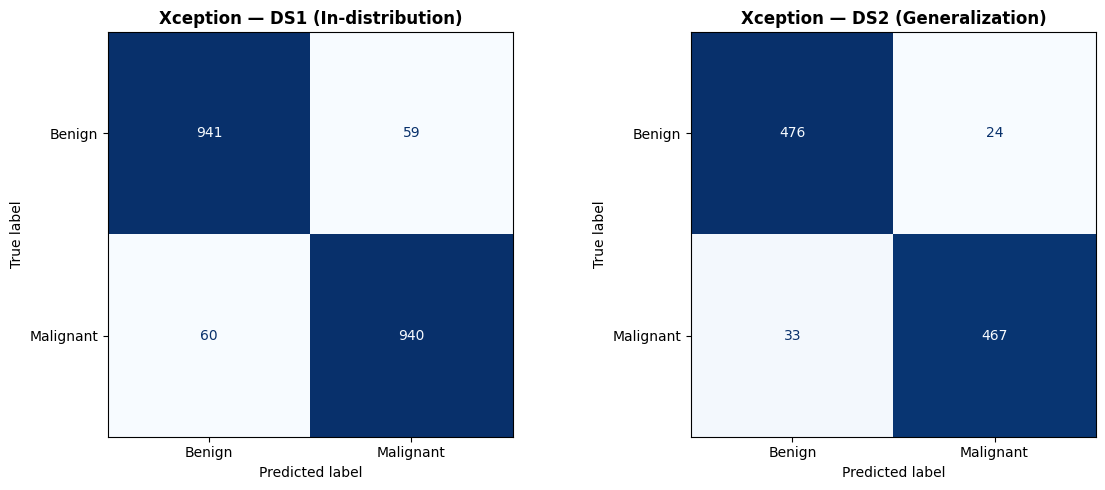

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# ── Path ──────────────────────────────────────────────────────────────
BASE = '/kaggle/working/full_pipeline_results'

# Load
probs_ds1  = np.load(f"{BASE}/probs_ds1_xception.npy")
labels_ds1 = np.load(f"{BASE}/ds1_labels.npy")
probs_ds2  = np.load(f"{BASE}/probs_ds2_xception.npy")
labels_ds2 = np.load(f"{BASE}/ds2_labels.npy")

# Convert predicted probabilities to class labels (threshold = 0.5)
preds_ds1 = (probs_ds1 >= 0.5).astype(int)
preds_ds2 = (probs_ds2 >= 0.5).astype(int)

# ── Plot confusion matrices ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (labels, preds, title) in zip(axes, [
    (labels_ds1, preds_ds1, "DS1 (In-distribution)"),
    (labels_ds2, preds_ds2, "DS2 (Generalization)"),
]):
    cm = confusion_matrix(labels, preds)
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=["Benign", "Malignant"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(f"Xception — {title}", fontweight="bold")

    tn, fp, fn, tp = cm.ravel()
    print(f"\n{title}")
    print(f"  TP: {tp}  FP: {fp}")
    print(f"  FN: {fn}  TN: {tn}")

plt.tight_layout()
plt.savefig(f"{BASE}/confusion_matrix_xception.png", dpi=150)
plt.show()

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# ── Adjust this path to match your local output directory ──────────
BASE = r"results/xception/full_pipeline_results"

# Load
probs_ds1  = np.load(os.path.join(BASE, "probs_ds1_xception.npy"))
labels_ds1 = np.load(os.path.join(BASE, "ds1_labels.npy"))

probs_ds2  = np.load(os.path.join(BASE, "probs_ds2_xception.npy"))
labels_ds2 = np.load(os.path.join(BASE, "ds2_labels.npy"))

# Convert predicted probabilities to class labels (threshold = 0.5)
preds_ds1 = (probs_ds1 >= 0.5).astype(int)
preds_ds2 = (probs_ds2 >= 0.5).astype(int)

# ── Plot confusion matrices ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (labels, preds, title) in zip(axes, [
    (labels_ds1, preds_ds1, "DS1"),
    (labels_ds2, preds_ds2, "DS2"),
]):
    cm = confusion_matrix(labels, preds)
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=["Benign", "Malignant"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(f"Xception — {title}", fontweight="bold")

    tn, fp, fn, tp = cm.ravel()
    print(f"\n{title}")
    print(f"  TP: {tp}  FP: {fp}")
    print(f"  FN: {fn}  TN: {tn}")

plt.tight_layout()
plt.savefig(os.path.join(BASE, "confusion_matrix_xception.png"), dpi=150)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'results/xception/full_pipeline_results/probs_ds1_xception.npy'